In [1]:
import os

root_dir = '/kaggle/input/lgg-mri-segmentation/kaggle_3m'
all_masks = []
all_images = []

for sub in os.listdir(root_dir):
    subdir = os.path.join(root_dir, sub)
    if os.path.isdir(subdir):  # <-- only loop into folders
        masks = [f for f in os.listdir(subdir) if f.endswith('_mask.tif')]
        images = [img.replace("_mask", "") for img in masks]

        all_masks.extend([os.path.join(subdir, f) for f in masks])
        all_images.extend([os.path.join(subdir, f) for f in images])

print(f"Found {len(all_images)} images and {len(all_masks)} masks")


Found 3929 images and 3929 masks


In [2]:
!pip install scikit-image


In [3]:
# Core libraries
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
plt.style.use('ggplot')
%matplotlib inline

# Data visualization
import os
from tqdm import tqdm, tnrange
import matplotlib.pyplot as plt
from skimage.io import imread, imshow, concatenate_images
from sklearn.model_selection import train_test_split
# TensorFlow and Keras imports
import tensorflow as tf
from sklearn import preprocessing
from tensorflow.keras.models import Model, load_model, save_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Additional TensorFlow components
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.losses import binary_crossentropy
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Conv2DTranspose, UpSampling2D,
    Dropout, Activation, concatenate, BatchNormalization, Add
)


2025-08-31 08:07:30.285908: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756627650.461493      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756627650.510797      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [4]:
WIDTH=256
HEIGHT=256
batch_size= 16

def plot_images(image_list , mask_list , pred_list , num_of_rows , figsize=(10,10)):
  if len(image_list) < num_of_rows or  not (len(image_list)==len(pred_list)==len(mask_list)):
    print("there is an error")
  else:
    plt.figure(figsize=figsize)
    for i in range (num_of_rows):
      # img = cv2.cvtColor(cv2.imread(image_list[i]), cv2.COLOR_BGR2RGB)
      # mask = cv2.imread(mask_list[i], cv2.IMREAD_GRAYSCALE)
      # pred = cv2.imread(pred_list[i], cv2.IMREAD_GRAYSCALE)
      img = image_list[i]
      mask = mask_list[i]
      pred = pred_list[i]


      plt.subplot(num_of_rows,3,3*i+1)
      plt.imshow(img)
      plt.title("image")
      plt.axis("off")


      plt.subplot(num_of_rows,3,3*i+2)
      plt.imshow(mask, cmap="gray")
      plt.title("True mask")
      plt.axis("off")


      plt.subplot(num_of_rows,3,3*i+3)
      plt.imshow(pred, cmap="gray")
      plt.title("Predicted mask")
      plt.axis("off")


    plt.tight_layout()
    plt.show()



In [5]:
df= pd.DataFrame(data={"image" : all_images , "mask" : all_masks})

In [6]:
train,test = train_test_split(df,test_size=.2)
test, val = train_test_split(test,test_size=.5)

print(f"train size : {train.shape}")
print(f"test size : {test.shape}")
print(f"val size : {val.shape}")


train size : (3143, 2)
test size : (393, 2)
val size : (393, 2)


In [7]:
def train_generator(data_frame, batch_size, augmentation_dict, image_color_mode="rgb", mask_color_mode="grayscale",image_save_prefix="image", mask_save_prefix="mask", save_to_dir=None, target_size=(256,256), seed=1):
        image_datagen = ImageDataGenerator(**augmentation_dict)
        mask_datagen  = ImageDataGenerator(**augmentation_dict)
        image_generator = image_datagen.flow_from_dataframe(
                            data_frame, x_col='image',
                            class_mode=None, color_mode=image_color_mode,
                            target_size=target_size, batch_size=batch_size,
                            save_to_dir=save_to_dir, save_prefix=image_save_prefix, seed=seed)

        mask_generator = mask_datagen.flow_from_dataframe(
                            data_frame, x_col='mask',
                            class_mode=None, color_mode=mask_color_mode,
                            target_size=target_size, batch_size=batch_size,
                            save_to_dir=save_to_dir, save_prefix=mask_save_prefix, seed=seed)

        train_gen = zip(image_generator, mask_generator)

        for (img, mask) in train_gen:

            img, mask = normalize_and_preprocess(img, mask)  # preprocessing step
            yield (img, mask)


In [8]:
def normalize_and_preprocess(img,mask):
  img /= 255
  mask /= 255
  mask[mask>0.5]=1
  mask[mask<=.5]=0
  return img , mask

In [9]:
def dice_coef(y_true,y_pred , smooth=1e-6):
  true_flatten = K.flatten(y_true)
  pred_flatten = K.flatten(y_pred)
  intersection= K.sum(true_flatten * pred_flatten)
  union = K.sum(true_flatten) + K.sum(pred_flatten)
  coef = (2 * intersection + smooth) / (union + smooth)
  return coef



In [10]:
def dice_loss(y_true , y_pred , smooth=1e-6):
  return 1-dice_coef(y_true,y_pred , smooth)

In [11]:
def bce_dice_loss(y_true, y_pred):
    return binary_crossentropy(y_true, y_pred) + dice_loss(y_true, y_pred)

In [12]:
def iou(y_true , y_pred , smooth=1e-6):

      true_flatten = K.flatten(y_true)
      pred_flatten = K.flatten(y_pred)
      intersection= K.sum(true_flatten * pred_flatten)
      union = K.sum(true_flatten) + K.sum(pred_flatten)
      iou = (intersection + smooth) / (union- intersection + smooth)
      return iou


In [13]:
def jaccard_distance(y_true, y_pred,smooth=1e-6):
  return 1 - iou(y_true , y_pred , smooth)

In [14]:
augmentation_dict = {
    "rotation_range": 15,
    "width_shift_range": 0.05,
    "height_shift_range": 0.05,
    "shear_range": 0.05,
    "zoom_range": 0.1,
    "horizontal_flip": True,
    "vertical_flip": True,
    "fill_mode": "nearest"
}


In [15]:
train_gen = train_generator(train, batch_size, augmentation_dict, target_size=(WIDTH,HEIGHT))
val_gen = train_generator(val, batch_size, augmentation_dict, target_size=(WIDTH,HEIGHT))

In [16]:
def conv_block(x, filters, num_convs=2, drop_out=0.0, residual=False):
    shortcut = x
    for _ in range(num_convs):
        x = Conv2D(filters, 3, padding="same", kernel_initializer="he_normal")(x)
        x = BatchNormalization()(x)
        x = Activation("relu")(x)
    if drop_out > 0:
        x = Dropout(drop_out)(x)
    if residual:
        if shortcut.shape[-1] != filters:
            shortcut = Conv2D(filters, 1, padding="same")(shortcut)
        x = Add()([x, shortcut])
    return x


def Unet( input_shape=(128, 128, 3), depth=4, num_filters=64, num_channels=1, drop_out=0.0, num_of_conv=2,  residual=False,upsampling="transpose"):
    inputs = Input(shape=input_shape)
    skips = []
    x = inputs

    # Encoder
    for i in range(depth):
        filters = (2 ** i) * num_filters
        x = conv_block(x, filters, num_convs=num_of_conv, drop_out=drop_out, residual=residual)
        skips.append(x)
        x = MaxPooling2D((2, 2))(x)

    # Bottleneck
    filters = (2 ** depth) * num_filters
    x = conv_block(x, filters, num_convs=num_of_conv, drop_out=drop_out, residual=residual)

    # Decoder
    for i in range(depth - 1, -1, -1):
        filters = (2 ** i) * num_filters
        if upsampling == "transpose":
            x = Conv2DTranspose(filters, 2, strides=(2, 2), padding="same")(x)
        else:
            x = UpSampling2D((2, 2))(x)
            x = Conv2D(filters, 2, padding="same")(x)
        x = concatenate([x, skips[i]])
        x = conv_block(x, filters, num_convs=num_of_conv, drop_out=drop_out, residual=residual)

    # Output
    x = Conv2D(num_channels, 1, padding="same")(x)
    x = Activation("sigmoid" if num_channels == 1 else "softmax")(x)

    return Model(inputs, x)


In [17]:
model = Unet( input_shape=(256, 256, 3), depth=4, num_filters=126, num_channels=1, drop_out=0.0, num_of_conv=2, residual= True,upsampling="upsampling")
lr = 1e-4
EPOCHS = 100
opt = Adam(learning_rate=lr)
checkpoint = ModelCheckpoint(
    "unet_best.h5",
    monitor="val_loss",
    verbose=1,
    save_best_only=True,
    mode="min"
)
early_stopping = EarlyStopping(
    monitor = "val_loss",
    patience = 20,
    verbose = 1,
    restore_best_weights = True
)
R = ReduceLROnPlateau(monitor="val_loss",
          factor=0.5, 
          patience=10, 
          verbose=1)

model.compile(optimizer=opt , loss = bce_dice_loss , metrics=["accuracy" , iou , dice_coef])


history = model.fit(
    train_gen,
    steps_per_epoch=len(train)//batch_size,
    validation_data=val_gen,
    validation_steps=len(val)//batch_size,
    epochs=EPOCHS ,
    callbacks=[ checkpoint,early_stopping, R],
    verbose=1
)



I0000 00:00:1756627662.260196      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 3143 validated image filenames.
Found 3143 validated image filenames.
Epoch 1/100


I0000 00:00:1756627693.365708     102 service.cc:148] XLA service 0x7b0740002290 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1756627693.366323     102 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1756627695.465614     102 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-08-31 08:09:07.989236: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng2{k2=3,k3=0} for conv (f32[16,252,256,256]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,126,256,256]{3,2,1,0}, f32[126,252,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]} is taking a while...
2025-08-31 08:09:08.265281: 

196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9855 - dice_coef: 0.4660 - iou: 0.3303 - loss: 0.6890Found 393 validated image filenames.
Found 393 validated image filenames.

Epoch 1: val_loss improved from inf to 0.92404, saving model to unet_best.h5
196/196 ━━━━━━━━━━━━━━━━━━━━ 623s 2s/step - accuracy: 0.9855 - dice_coef: 0.4664 - iou: 0.3307 - loss: 0.6883 - val_accuracy: 0.9907 - val_dice_coef: 0.1418 - val_iou: 0.0820 - val_loss: 0.9240 - learning_rate: 1.0000e-04
Epoch 2/100


E0000 00:00:1756628331.666723     103 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1756628331.900716     103 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-08-31 08:18:53.846696: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng0{} for conv (f32[126,126,3,3]{3,2,1,0}, u8[0]{0}) custom-call(f32[7,126,256,256]{3,2,1,0}, f32[7,126,256,256]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardFilter", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]} is taking a while...
2025-08-31 08:18:55.3

196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9936 - dice_coef: 0.6313 - iou: 0.4779 - loss: 0.4211
Epoch 2: val_loss improved from 0.92404 to 0.42920, saving model to unet_best.h5
196/196 ━━━━━━━━━━━━━━━━━━━━ 471s 2s/step - accuracy: 0.9936 - dice_coef: 0.6313 - iou: 0.4779 - loss: 0.4211 - val_accuracy: 0.9935 - val_dice_coef: 0.6098 - val_iou: 0.4552 - val_loss: 0.4292 - learning_rate: 1.0000e-04
Epoch 3/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9945 - dice_coef: 0.6695 - iou: 0.5275 - loss: 0.3588

E0000 00:00:1756629114.753931     103 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1756629114.988679     103 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 3: val_loss improved from 0.42920 to 0.36824, saving model to unet_best.h5
196/196 ━━━━━━━━━━━━━━━━━━━━ 390s 2s/step - accuracy: 0.9945 - dice_coef: 0.6695 - iou: 0.5275 - loss: 0.3588 - val_accuracy: 0.9941 - val_dice_coef: 0.6742 - val_iou: 0.5321 - val_loss: 0.3682 - learning_rate: 1.0000e-04
Epoch 4/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9949 - dice_coef: 0.7077 - iou: 0.5647 - loss: 0.3312
Epoch 4: val_loss improved from 0.36824 to 0.31577, saving model to unet_best.h5
196/196 ━━━━━━━━━━━━━━━━━━━━ 364s 2s/step - accuracy: 0.9949 - dice_coef: 0.7077 - iou: 0.5647 - loss: 0.3312 - val_accuracy: 0.9956 - val_dice_coef: 0.7236 - val_iou: 0.5836 - val_loss: 0.3158 - learning_rate: 1.0000e-04
Epoch 5/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9947 - dice_coef: 0.7111 - iou: 0.5702 - loss: 0.3287
Epoch 5: val_loss did not improve from 0.31577
196/196 ━━━━━━━━━━━━━━━━━━━━ 359s 2s/step - accuracy: 0.9947 - dice_coef: 0.7110 - iou: 0.5702 - loss: 0.3

In [92]:
test_x = np.array([imread(img) for img in test["image"]],dtype=np.float32)
test_y = np.array([imread(mask) for mask in test["mask"]],dtype=np.float32)
test_x /= 255.0
test_pred = model.predict(test_x)
train_x = np.array([imread(img) for img in train["image"]],dtype=np.float32)
train_y = np.array([imread(mask) for mask in train["mask"]],dtype=np.float32)
train_x /= 255.0
train_pred = model.predict(train_x)
val_x = np.array([imread(img) for img in val["image"]],dtype=np.float32)
val_y = np.array([imread(mask) for mask in val["mask"]],dtype=np.float32)
val_x /= 255.0
val_pred = model.predict(val_x)


13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step


In [111]:
idx= np.random.randint(0,len(X))
num_of_rows = 7
image_list = X[idx:idx+num_of_rows+1]
mask_list =  Y[idx:idx+num_of_rows+1]
pred_list = pred[idx:idx+num_of_rows+1]

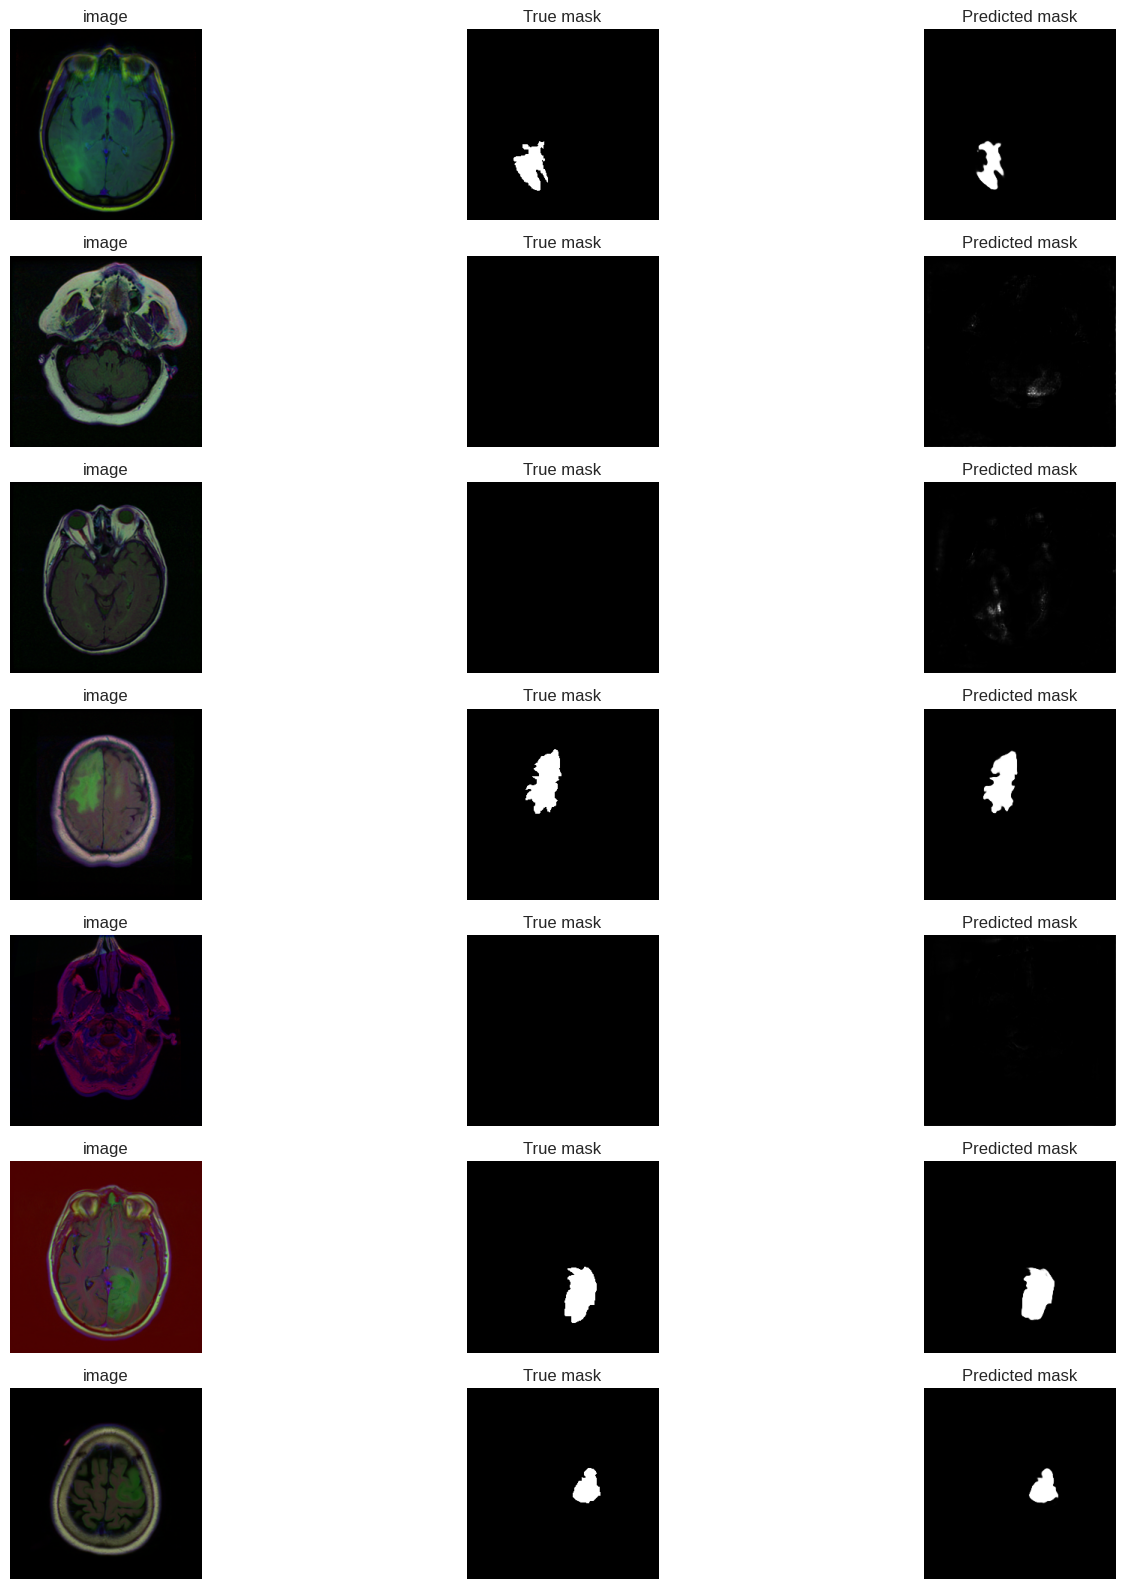

In [112]:
plot_images(image_list , mask_list , pred_list , num_of_rows , figsize=(16,16))

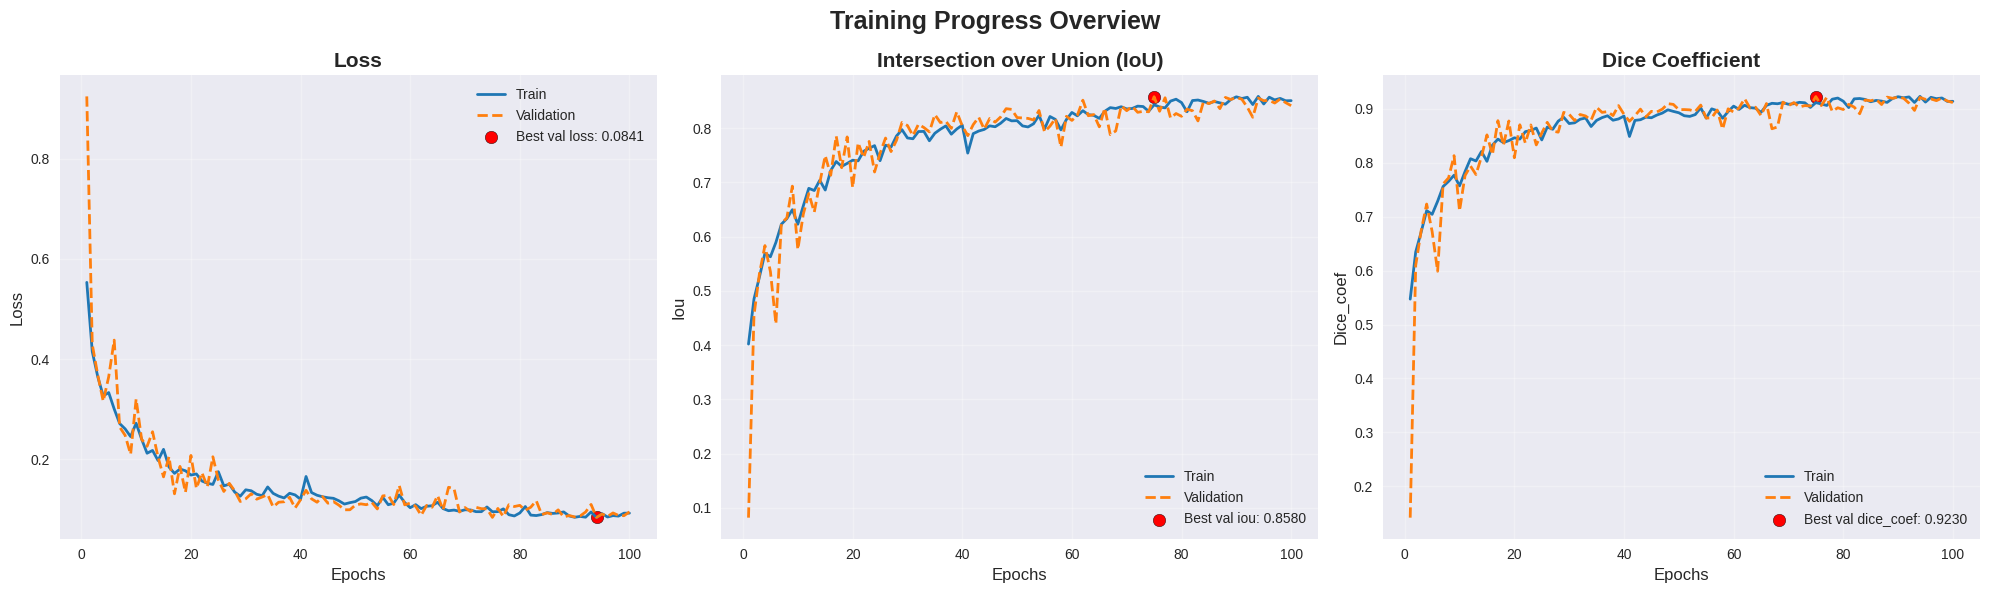

In [102]:
import matplotlib.pyplot as plt
import numpy as np

def plot_training(history):
    metrics = ["loss", "iou", "dice_coef"]
    titles = {
        "loss": "Loss",
        "iou": "Intersection over Union (IoU)",
        "dice_coef": "Dice Coefficient"
    }

    plt.style.use("seaborn-v0_8")
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    for i, metric in enumerate(metrics):
        ax = axes[i]

        train = history.history[metric]
        val = history.history[f"val_{metric}"]
        epochs = np.arange(1, len(train) + 1)

        # Plot curves
        ax.plot(epochs, train, label="Train", linewidth=2, color="tab:blue")
        ax.plot(epochs, val, label="Validation", linewidth=2, color="tab:orange", linestyle="--")

        # Mark best validation point
        if metric == "loss":
            best_idx = np.argmin(val)
        else:
            best_idx = np.argmax(val)

        ax.scatter(epochs[best_idx], val[best_idx], s=80, 
                   color="red", marker="o", edgecolor="k", 
                   label=f"Best val {metric}: {val[best_idx]:.4f}")

        # Titles and labels
        ax.set_title(titles[metric], fontsize=15, fontweight="bold")
        ax.set_xlabel("Epochs", fontsize=12)
        ax.set_ylabel(metric.capitalize(), fontsize=12)
        ax.grid(alpha=0.3)
        ax.legend()

    fig.suptitle("Training Progress Overview", fontsize=18, fontweight="bold")
    plt.tight_layout()
    plt.show()

# Call it
plot_training(history)


In [97]:
train_y = (train_y > 127).astype(np.float32)
val_y   = (val_y > 127).astype(np.float32)
test_y  = (test_y > 127).astype(np.float32)
train_dice_coef= dice_coef(train_y,train_pred)
train_iou = iou(train_y,train_pred)
val_dice_coef= dice_coef(val_y,val_pred)
val_iou = iou(val_y,val_pred)
test_dice_coef= dice_coef(test_y,test_pred)
test_iou = iou(test_y,test_pred)

In [99]:

metrics = {
    "Dataset": ["Train", "Validation", "Test"],
    "Dice Coefficient": [
        float(train_dice_coef.numpy() if hasattr(train_dice_coef, "numpy") else train_dice_coef),
        float(val_dice_coef.numpy() if hasattr(val_dice_coef, "numpy") else val_dice_coef),
        float(test_dice_coef.numpy() if hasattr(test_dice_coef, "numpy") else test_dice_coef)
    ],
    "IoU": [
        float(train_iou.numpy() if hasattr(train_iou, "numpy") else train_iou),
        float(val_iou.numpy() if hasattr(val_iou, "numpy") else val_iou),
        float(test_iou.numpy() if hasattr(test_iou, "numpy") else test_iou)
    ]
}


df = pd.DataFrame(metrics)
df


,Dataset,Dice Coefficient,IoU
0,Train,0.930945,0.870811
1,Validation,0.922122,0.855498
2,Test,0.917176,0.847022


In [ ]:
model.save("/kaggle/working/my_model.h5")
